# CODICE TESI 


## 1. Import libraries and configuration

In [1]:
import glob
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Utility functions

In [2]:
def clean_company_id(series: pd.Series) -> pd.Series:
    """Clean fiscal/tax codes used as merge keys.

    The function removes spaces, uppercases text, removes trailing .0 created by Excel,
    and converts empty or invalid strings to missing values.
    """
    cleaned = (
        series
        .astype("string")
        .str.strip()
        .str.upper()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(r"\.0$", "", regex=True)
    )
    cleaned = cleaned.replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA, "<NA>": pd.NA})
    return cleaned


def clean_euro_amount(series: pd.Series) -> pd.Series:
    """Convert Italian/European euro-formatted strings into numeric values."""
    cleaned = (
        series
        .astype("string")
        .str.replace("€", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    return pd.to_numeric(cleaned, errors="coerce")


def clean_thousand_number(series: pd.Series) -> pd.Series:
    """Clean AIDA numeric columns expressed in thousands of euros."""
    cleaned = (
        series
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    return pd.to_numeric(cleaned, errors="coerce")


def classify_subsidy(amount: float) -> str:
    if pd.isna(amount):
        return "missing"
    if amount < 5000:
        return "small_subsidies"
    if amount < 50000:
        return "medium_subsidies"
    if amount < 200000:
        return "large_subsidies"
    return "very_large"

## 3. Import RNA subsidy files

In [3]:
csv_files = sorted(SUBSIDIES_FOLDER.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {SUBSIDIES_FOLDER.resolve()}")

files = []
for fname in csv_files:
    print(f"Reading: {fname}")
    df = pd.read_csv(
        fname,
        dtype={
            "Identificativo nazionale": "string",
            "Importo nominale": "string",
            "Elemento di aiuto": "string",
        },
        low_memory=False,
    )
    
    files.append(df)

merge = pd.concat(files, ignore_index=True)
print("Merged subsidy rows:", merge.shape)
merge.head()

Reading: FILE SUSSIDI/3.csv
Reading: FILE SUSSIDI/34_trasparenza_ce (10).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (11).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (12).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (13).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (14).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (15).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (17).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (18).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (19).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (2).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (20).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (21).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (22).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (23).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (24).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (25).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (3).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (4).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (5).csv
Reading: FILE SUSSIDI/34_trasparenza_ce (6).c

,Paese,Denominazione della misura,Codice CE,CAR,Identificativo Aiuto (TAM),COR,Altro Stato membro beneficiario,Paese extra UE,Identificativo nazionale,Denominazione Beneficiario,Tipo di beneficiario,Regione,Settore (NACE),Strumento di aiuto,Obiettivo dell'aiuto,Importo nominale,Elemento di aiuto,Data di concessione,Nome dell'Autorità,Entità delegata,Intermediari finanziari,Data di pubblicazione
0,Italia,Misura TECNONIDI (Art. 22 del GBER: Aiuti alle...,SA.111251,28318,NaN,22743346,NaN,NaN,02683850743,RTLP SRL,PMI,Puglia,J.62.0,Prestito/Anticipo rimborsabile,CE651/2014 - Aiuti per l'accesso delle PMI ai ...,"€ 99.980,00","€ 99.980,00",20/09/2024,Regione Puglia,NaN,NaN,21/09/2024
1,Italia,Misura TECNONIDI (Art. 22 del GBER: Aiuti alle...,SA.111251,28318,NaN,22743346,NaN,NaN,02683850743,RTLP SRL,PMI,Puglia,J.62.0,Sovvenzione/Contributo in conto interessi,CE651/2014 - Aiuti per l'accesso delle PMI ai ...,"€ 80.000,00","€ 80.000,00",20/09/2024,Regione Puglia,NaN,NaN,21/09/2024
2,Italia,Misura TECNONIDI (Art. 22 del GBER: Aiuti alle...,SA.111251,28318,NaN,22743346,NaN,NaN,02683850743,RTLP SRL,PMI,Puglia,J.62.0,Sovvenzione/Contributo in conto interessi,CE651/2014 - Aiuti per l'accesso delle PMI ai ...,"€ 99.980,00","€ 99.980,00",20/09/2024,Regione Puglia,NaN,NaN,21/09/2024
3,Italia,Bando Voucher Internazionalizzazione - Anno 2025,NaN,31780,NaN,24369803,NaN,NaN,08675350725,NEBRA SKAY S.R.L.,PMI,Puglia,C.14.1,Sovvenzione/Contributo in conto interessi,CE2831/23 - Promozione dell'esportazione e del...,"€ 4.970,00","€ 4.970,00",06/06/2025,Camera di Commercio Industria Artigianato e Ag...,NaN,NaN,07/06/2025
4,Italia,Incentivi fiscali per investimenti in start up...,NaN,16916,NaN,22400777,NaN,NaN,08675350725,NEBRA SKAY S.R.L.,PMI,Puglia,C.14.1,Agevolazione fiscale o esenzione fiscale,CE1407/13 - Altro obiettivo di sviluppo econom...,"€ 10.000,00","€ 10.000,00",14/05/2024,Ministero delle Imprese e del Made in Italy,NaN,NaN,15/05/2024


## 4. Export raw merged file and remove duplicates

In [4]:
merge.to_csv(OUTPUT_MERGE_DUPLICATES, index=False)

remove_dup = merge.drop_duplicates().copy()
print("Rows before duplicates removal:", merge.shape[0])
print("Rows after duplicates removal:", remove_dup.shape[0])

Rows before duplicates removal: 2453
Rows after duplicates removal: 1352


## 5. Clean subsidy dates, amounts and company identifiers

In [5]:
required_columns = ["Identificativo nazionale", "Data di concessione", "Elemento di aiuto"]
missing_columns = [col for col in required_columns if col not in remove_dup.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in subsidy files: {missing_columns}")

remove_dup["Identificativo nazionale"] = clean_company_id(remove_dup["Identificativo nazionale"])
remove_dup["Data di concessione"] = pd.to_datetime(remove_dup["Data di concessione"], format="%d/%m/%Y", errors="coerce")
remove_dup["Elemento di aiuto Clean"] = clean_euro_amount(remove_dup["Elemento di aiuto"])

print("Missing company IDs:", remove_dup["Identificativo nazionale"].isna().sum())
print("Missing dates:", remove_dup["Data di concessione"].isna().sum())
print("Missing subsidy amounts:", remove_dup["Elemento di aiuto Clean"].isna().sum())
remove_dup[["Identificativo nazionale", "Data di concessione", "Elemento di aiuto", "Elemento di aiuto Clean"]].head()

Missing company IDs: 0
Missing dates: 0
Missing subsidy amounts: 0


,Identificativo nazionale,Data di concessione,Elemento di aiuto,Elemento di aiuto Clean
0,02683850743,2024-09-20,"€ 99.980,00",99980.0
1,02683850743,2024-09-20,"€ 80.000,00",80000.0
2,02683850743,2024-09-20,"€ 99.980,00",99980.0
3,08675350725,2025-06-06,"€ 4.970,00",4970.0
4,08675350725,2024-05-14,"€ 10.000,00",10000.0


## 6. Filter subsidies

In [6]:
# Keep subsidies above 1,000 euro and granted up to 31/12/2022.
# The original notebook comment said "since 31/12/2022", but the code used <= 31/12/2022.
# This keeps the original code logic: up to 31/12/2022.
cutoff_date = pd.Timestamp("2022-12-31")

mask_finale = (
    (remove_dup["Elemento di aiuto Clean"] > 1000)
    & (remove_dup["Data di concessione"] <= cutoff_date)
    & (remove_dup["Identificativo nazionale"].notna())
)

remove_dup = remove_dup.loc[mask_finale].copy()
print("Filtered subsidy rows:", remove_dup.shape)
remove_dup.head()

Filtered subsidy rows: (346, 23)


,Paese,Denominazione della misura,Codice CE,CAR,Identificativo Aiuto (TAM),COR,Altro Stato membro beneficiario,Paese extra UE,Identificativo nazionale,Denominazione Beneficiario,Tipo di beneficiario,Regione,Settore (NACE),Strumento di aiuto,Obiettivo dell'aiuto,Importo nominale,Elemento di aiuto,Data di concessione,Nome dell'Autorità,Entità delegata,Intermediari finanziari,Data di pubblicazione,Elemento di aiuto Clean
9,Italia,Smart Money - Incentivi per le nuove start up ...,NaN,16619,NaN,8652235,NaN,NaN,08675350725,NEBRA SKAY SRL,PMI,Puglia,C.14.1,Sovvenzione/Contributo in conto interessi,"CE1407/13 - Ricerca, sviluppo e innovazione","€ 12.500,00","€ 10.000,00",2022-03-25,Ministero delle Imprese e del Made in Italy,NaN,NaN,26/03/2022,10000.0
62,Italia,Fondo di garanzia per le piccole e medie imprese,SA.60791,16617,NaN,10080849,NaN,NaN,05160240759,BRANDERS S.R.L.,PMI,Puglia,C.17.2,Garanzia (se del caso con un riferimento alla ...,CE1407/13 - PMI,"€ 64.000,00","€ 1.235,20",2022-12-16,Ministero delle Imprese e del Made in Italy,NaN,NaN,17/12/2022,1235.2
63,Italia,Fondo di garanzia per le piccole e medie imprese,SA.60791,16617,NaN,10083872,NaN,NaN,05160240759,BRANDERS S.R.L.,PMI,Puglia,C.17.2,Garanzia (se del caso con un riferimento alla ...,CE1407/13 - PMI,"€ 80.000,00","€ 5.269,22",2022-12-16,Ministero delle Imprese e del Made in Italy,NaN,NaN,17/12/2022,5269.22
64,Italia,[Titolo III] Regolamento regionale della Pugli...,SA.105778,16551,NaN,9272279,NaN,NaN,05160240759,BRANDERS S.R.L.,PMI,Puglia,C.17.2,Prestito/Anticipo rimborsabile,CE651/2014 - Aiuti per l'accesso delle PMI ai ...,"€ 99.705,20","€ 99.705,20",2022-09-23,Regione Puglia,NaN,NaN,24/09/2022,99705.2
65,Italia,[Titolo III] Regolamento regionale della Pugli...,SA.105778,16551,NaN,9272279,NaN,NaN,05160240759,BRANDERS S.R.L.,PMI,Puglia,C.17.2,Sovvenzione/Contributo in conto interessi,CE651/2014 - Aiuti per l'accesso delle PMI ai ...,"€ 33.561,93","€ 33.561,93",2022-09-23,Regione Puglia,NaN,NaN,24/09/2022,33561.93


## 7. Classify subsidies

In [7]:
remove_dup["Category of the Subsidy"] = remove_dup["Elemento di aiuto Clean"].apply(classify_subsidy)

concentration_subsidies = remove_dup["Category of the Subsidy"].value_counts()
concentration_subsidies_perc = remove_dup["Category of the Subsidy"].value_counts(normalize=True) * 100

print(concentration_subsidies)
print(concentration_subsidies_perc.round(2))

Category of the Subsidy
medium_subsidies    173
small_subsidies     112
large_subsidies      57
very_large            4
Name: count, dtype: int64
Category of the Subsidy
medium_subsidies    50.00
small_subsidies     32.37
large_subsidies     16.47
very_large           1.16
Name: proportion, dtype: float64


## 8. Aggregate subsidies per firm

In [8]:
category_subsidies_per_firm = (
    remove_dup
    .groupby(["Identificativo nazionale", "Category of the Subsidy"], dropna=False)["Elemento di aiuto Clean"]
    .count()
    .reset_index()
    .rename(columns={"Elemento di aiuto Clean": "Count Category of Subsidy"})
)

pivot_table_categories_across_firm = (
    category_subsidies_per_firm
    .pivot_table(
        values="Count Category of Subsidy",
        index="Identificativo nazionale",
        columns="Category of the Subsidy",
        fill_value=0,
        aggfunc="sum",
    )
)

# Guarantee that all expected category columns exist, even if one category is absent.
expected_categories = ["small_subsidies", "medium_subsidies", "large_subsidies", "very_large"]
for col in expected_categories:
    if col not in pivot_table_categories_across_firm.columns:
        pivot_table_categories_across_firm[col] = 0

pivot_table_categories_across_firm = pivot_table_categories_across_firm[expected_categories].astype(int)
pivot_table_categories_across_firm["All"] = pivot_table_categories_across_firm.sum(axis=1)

print(pivot_table_categories_across_firm.head())

Category of the Subsidy   small_subsidies  medium_subsidies  large_subsidies  very_large  All
Identificativo nazionale                                                                     
02589140744                             1                 2                2           0    5
02623080740                             4                 6                0           0   10
02630470744                             9                 9                3           0   21
02631640741                             1                 0                0           0    1
02644680742                             0                 5                2           0    7


In [9]:
total_subsidies_per_company = (
    remove_dup
    .groupby("Identificativo nazionale", as_index=False)["Elemento di aiuto Clean"]
    .sum()
    .sort_values("Elemento di aiuto Clean", ascending=False)
)

total_subsidies_per_company.to_csv(OUTPUT_SUBSIDIES_PER_COMPANY, index=False)
print("Companies with subsidies:", total_subsidies_per_company.shape[0])
total_subsidies_per_company.head()

Companies with subsidies: 79


,Identificativo nazionale,Elemento di aiuto Clean
74,08605990723,610127.12
18,05085600756,470511.56
2,02630470744,412176.49
25,05111540752,361825.29
37,05170070758,316282.09


## 9. Import startup file and clean startup IDs

In [10]:
start_up_puglia = pd.read_csv(STARTUP_FILE, dtype={"codice fiscale": "string"}, low_memory=False)

if "codice fiscale" not in start_up_puglia.columns:
    raise ValueError("Column 'codice fiscale' not found in startup file. Check the column name.")

start_up_puglia = start_up_puglia.copy()
start_up_puglia["codice fiscale_clean"] = clean_company_id(start_up_puglia["codice fiscale"])

print("Startup rows:", start_up_puglia.shape[0])
print("Unique startup fiscal codes:", start_up_puglia["codice fiscale_clean"].nunique(dropna=True))
print("Missing startup fiscal codes:", start_up_puglia["codice fiscale_clean"].isna().sum())
start_up_puglia.head()

Startup rows: 153
Unique startup fiscal codes: 153
Missing startup fiscal codes: 0


,denominazione,nat.giuridica,codice fiscale,pv,comune,data iscrizione alla sezione delle startup,Unnamed: 6,data iscrizione al Registro Imprese,data inizio dell'esercizio effettivo dell'attività,ateco 2007,settore,attività,classe di produzione ultimo anno (1),classe di addetti ultimo anno (2),impresa a vocazione sociale (5),impresa ad alto valore tecnologico in ambito energetico(4),classe di capitale (3),sito internet,1° req.\n(6),2° req.\n(6),3° req.\n(6),data dichiarazione\n(7),prevalenza femminile (8),prevalenza giovanile (8),prevalenza straniera (8),codice fiscale_clean
0,ENVIRON ENERGY SOLUTION S.R.L.,SOCIETA' A RESPONSABILITA' LIMITATA,05241520757,LE,GIURDIGNANO,31/08/2022,2022,31/08/2022,15/08/2022,721029,SERVIZI,M 72 RICERCA SCIENTIFICA E SVILUPPO,NaN,NaN,NaN,SI,3,NaN,NaN,NaN,SI,19/09/2024,NO,NO,NO,05241520757
1,HYBA S.R.L.,SOCIETA' A RESPONSABILITA' LIMITATA,05230030750,LE,LECCE,30/09/2022,2022,07/06/2022,NaN,272000,INDUSTRIA/ARTIGIANATO,C 27 FABBRICAZIONE DI APPARECCHIATURE ELETTRIC...,A,A,NaN,SI,6,https://www.hyba.eu,NaN,NaN,SI,03/09/2024,NO,NO,NO,05230030750
2,6DOF LABS S.R.L.,SOCIETA' A RESPONSABILITA' LIMITATA,05226230752,LE,SQUINZANO,30/05/2022,2022,30/05/2022,12/05/2022,262000,INDUSTRIA/ARTIGIANATO,C 26 FABBRICAZIONE DI COMPUTER E PRODOTTI DI E...,B,A,NaN,NO,3,NaN,NaN,NaN,SI,21/06/2023,NO,Esclusiva,NO,05226230752
3,CRHACK LAB BARI- OFFICINE DI CULTURA DIGITALE ...,SOCIETA' A RESPONSABILITA' LIMITATA,08693310727,BA,MOLFETTA,29/04/2022,2022,29/04/2022,20/04/2022,629009,SERVIZI,"J 62 PRODUZIONE DI SOFTWARE, CONSULENZA INFORM...",A,NaN,NaN,NO,3,www.crhacklabbari.com,SI,NaN,NaN,09/07/2024,NO,Forte,NO,08693310727
4,SOUTHCOBOTICS S.R.L. ...,SOCIETA' A RESPONSABILITA' LIMITATA,08540600726,BA,RUTIGLIANO,28/11/2022,2022,12/03/2021,31/07/2024,264009,INDUSTRIA/ARTIGIANATO,C 26 FABBRICAZIONE DI COMPUTER E PRODOTTI DI E...,A,NaN,NaN,NO,2,southcobotics.eu,SI,NaN,NaN,23/10/2025,NO,NO,NO,08540600726


## 10. Diagnostic check before anti-join

In [11]:
startup_ids = set(start_up_puglia["codice fiscale_clean"].dropna())
subsidy_ids = set(total_subsidies_per_company["Identificativo nazionale"].dropna())
matched_ids = startup_ids & subsidy_ids

print("Startup IDs:", len(startup_ids))
print("Subsidy IDs:", len(subsidy_ids))
print("Matched IDs:", len(matched_ids))

if len(matched_ids) == 0:
    print("WARNING: zero matches. This is not an anti-join problem: the two ID columns do not contain the same cleaned values.")
    print("Examples from startup IDs:", list(sorted(startup_ids))[:10])
    print("Examples from subsidy IDs:", list(sorted(subsidy_ids))[:10])

Startup IDs: 153
Subsidy IDs: 79
Matched IDs: 79


## 11. Anti-join: startups that did not receive subsidies

In [12]:
anti_join = start_up_puglia.merge(
    total_subsidies_per_company,
    left_on="codice fiscale_clean",
    right_on="Identificativo nazionale",
    how="left",
    indicator=True,
)

print(anti_join["_merge"].value_counts())

# Correct anti-join: keep rows present only in the startup file.
columns_to_export = [col for col in ["denominazione", "codice fiscale", "codice fiscale_clean"] if col in anti_join.columns]
non_presenti = anti_join.loc[anti_join["_merge"] == "left_only", columns_to_export].copy()

non_presenti.to_csv(OUTPUT_NOT_PRESENT, index=False)
print("Startups without subsidies:", non_presenti.shape[0])
non_presenti.head()

_merge
both          79
left_only     74
right_only     0
Name: count, dtype: int64
Startups without subsidies: 74


,denominazione,codice fiscale,codice fiscale_clean
0,ENVIRON ENERGY SOLUTION S.R.L.,05241520757,05241520757
1,HYBA S.R.L.,05230030750,05230030750
2,6DOF LABS S.R.L.,05226230752,05226230752
3,CRHACK LAB BARI- OFFICINE DI CULTURA DIGITALE ...,08693310727,08693310727
5,CONDIVISION SYSTEMS S.R.L.,08679500721,08679500721


## 12. Startups that received subsidies

In [13]:
startup_with_subsidies = anti_join.loc[anti_join["_merge"] == "both"].copy()
print("Startups with subsidies:", startup_with_subsidies.shape[0])
startup_with_subsidies.head()

Startups with subsidies: 79


,denominazione,nat.giuridica,codice fiscale,pv,comune,data iscrizione alla sezione delle startup,Unnamed: 6,data iscrizione al Registro Imprese,data inizio dell'esercizio effettivo dell'attività,ateco 2007,settore,attività,classe di produzione ultimo anno (1),classe di addetti ultimo anno (2),impresa a vocazione sociale (5),impresa ad alto valore tecnologico in ambito energetico(4),classe di capitale (3),sito internet,1° req.\n(6),2° req.\n(6),3° req.\n(6),data dichiarazione\n(7),prevalenza femminile (8),prevalenza giovanile (8),prevalenza straniera (8),codice fiscale_clean,Identificativo nazionale,Elemento di aiuto Clean,_merge
4,SOUTHCOBOTICS S.R.L. ...,SOCIETA' A RESPONSABILITA' LIMITATA,08540600726,BA,RUTIGLIANO,28/11/2022,2022,12/03/2021,31/07/2024,264009,INDUSTRIA/ARTIGIANATO,C 26 FABBRICAZIONE DI COMPUTER E PRODOTTI DI E...,A,NaN,NaN,NO,2,southcobotics.eu,SI,NaN,NaN,23/10/2025,NO,NO,NO,08540600726,08540600726,70171.15,both
9,HYDROGEN ARA (HYDROGEN RESEARCH AND ACCADEMY) SRL,SOCIETA' A RESPONSABILITA' LIMITATA,03351110733,TA,TARANTO,26/10/2022,2022,26/10/2022,20/09/2022,271200,INDUSTRIA/ARTIGIANATO,C 27 FABBRICAZIONE DI APPARECCHIATURE ELETTRIC...,B,A,NaN,SI,7,hydrogenarea.register.it.simply.site,SI,NaN,NaN,26/10/2022,NO,NO,NO,03351110733,03351110733,7500.0,both
14,ITALIAN WIND TECHNOLOGIES SOCIETA' A RESPONSA...,SOCIETA' A RESPONSABILITA' LIMITATA,08543100724,BA,ALTAMURA,24/11/2022,2022,15/03/2021,26/02/2021,281120,INDUSTRIA/ARTIGIANATO,C 28 FABBRICAZIONE DI MACCHINARI ED APPARECCHI...,B,A,NaN,SI,4,https://www.italianwindtech.com/,SI,NaN,NaN,23/10/2025,NO,NO,NO,08543100724,08543100724,33677.07,both
19,UNEXPECTED ITALY S.R.L. SOCIETA' BENEFIT,SOCIETA' A RESPONSABILITA' LIMITATA,08704360729,BA,BARI,23/08/2022,2022,26/05/2022,06/06/2022,639100,SERVIZI,J 63 ATTIVITA' DEI SERVIZI D'INFORMAZIONE E AL...,A,A,NaN,NO,3,unexpected-italy.com,SI,NaN,NaN,22/10/2025,Maggioritaria,NO,NO,08704360729,08704360729,72315.51,both
24,ARCHIMED SOCIETA' A RESPONSABILITA' LIMITATA S...,SOCIETA' A RESPONSABILITA' LIMITATA SEMPLIFICATA,08587410724,BA,ACQUAVIVA DELLE FONTI,21/11/2022,2022,30/06/2021,24/01/2022,325020,INDUSTRIA/ARTIGIANATO,C 32 ALTRE INDUSTRIE MANIFATTURIERE,A,NaN,NaN,NO,2,www.ortopedia3d.net,SI,NaN,NaN,15/09/2025,NO,Esclusiva,NO,08587410724,08587410724,30000.0,both


## 13. Import AIDA financial data

In [14]:
aida = pd.read_csv(AIDA_FILE, dtype={"Tax code number": "string"}, low_memory=False)

if "Tax code number" not in aida.columns:
    raise ValueError("Column 'Tax code number' not found in AIDA file. Check the column name.")

aida = aida.copy()
aida["Tax code number_clean"] = clean_company_id(aida["Tax code number"])

print("AIDA rows:", aida.shape[0])
print("Unique AIDA tax codes:", aida["Tax code number_clean"].nunique(dropna=True))
aida.head()

AIDA rows: 153
Unique AIDA tax codes: 153


,Unnamed: 0,Company name,Province,Accounting closing date\nLast avail. yr,Number of employees\nLast avail. yr,Tax code number,CCIAA number,EBITDA\nth EUR\nLast avail. yr,EBITDA\nth EUR\n2024,EBITDA\nth EUR\n2023,EBITDA\nth EUR\n2022,EBITDA\nth EUR\n2021,EBITDA\nth EUR\n2020,EBITDA\nth EUR\n2019,EBITDA\nth EUR\n2018,EBITDA\nth EUR\n2017,EBITDA\nth EUR\n2016,EBITDA\nth EUR\n2015,Revenues from sales and services\nth EUR\nLast avail. yr,Revenues from sales and services\nth EUR\n2024,Revenues from sales and services\nth EUR\n2023,Revenues from sales and services\nth EUR\n2022,Revenues from sales and services\nth EUR\n2021,Revenues from sales and services\nth EUR\n2020,Revenues from sales and services\nth EUR\n2019,Revenues from sales and services\nth EUR\n2018,Revenues from sales and services\nth EUR\n2017,Revenues from sales and services\nth EUR\n2016,Revenues from sales and services\nth EUR\n2015,Total shareholder's funds\nth EUR\nLast avail. yr,Total shareholder's funds\nth EUR\n2024,Total shareholder's funds\nth EUR\n2023,Total shareholder's funds\nth EUR\n2022,Total shareholder's funds\nth EUR\n2021,Total shareholder's funds\nth EUR\n2020,Total shareholder's funds\nth EUR\n2019,Total shareholder's funds\nth EUR\n2018,Total shareholder's funds\nth EUR\n2017,Total shareholder's funds\nth EUR\n2016,Total shareholder's funds\nth EUR\n2015,Total assets\nth EUR\nLast avail. yr,Total assets\nth EUR\n2024,Total assets\nth EUR\n2023,Total assets\nth EUR\n2022,Total assets\nth EUR\n2021,Total assets\nth EUR\n2020,Total assets\nth EUR\n2019,Total assets\nth EUR\n2018,Total assets\nth EUR\n2017,Total assets\nth EUR\n2016,Total assets\nth EUR\n2015,Profit (loss)\nth EUR\nLast avail. yr,Profit (loss)\nth EUR\n2024,Profit (loss)\nth EUR\n2023,Profit (loss)\nth EUR\n2022,Profit (loss)\nth EUR\n2021,Profit (loss)\nth EUR\n2020,Profit (loss)\nth EUR\n2019,Profit (loss)\nth EUR\n2018,Profit (loss)\nth EUR\n2017,Profit (loss)\nth EUR\n2016,Profit (loss)\nth EUR\n2015,Added Value\nth EUR\nLast avail. yr,Added Value\nth EUR\n2024,Added Value\nth EUR\n2023,Added Value\nth EUR\n2022,Added Value\nth EUR\n2020,Added Value\nth EUR\n2021,Added Value\nth EUR\n2019,Added Value\nth EUR\n2018,Added Value\nth EUR\n2017,Added Value\nth EUR\n2016,Added Value\nth EUR\n2015,Turnover per employee\nEUR\nLast avail. yr,Turnover per employee\nEUR\n2024,Turnover per employee\nEUR\n2023,Turnover per employee\nEUR\n2022,Turnover per employee\nEUR\n2021,Turnover per employee\nEUR\n2020,Turnover per employee\nEUR\n2019,Turnover per employee\nEUR\n2018,Turnover per employee\nEUR\n2017,Turnover per employee\nEUR\n2016,Turnover per employee\nEUR\n2015,Total personnel costs\nth EUR\nLast avail. yr,Total personnel costs\nth EUR\n2024,Total personnel costs\nth EUR\n2023,Total personnel costs\nth EUR\n2022,Total personnel costs\nth EUR\n2020,Total personnel costs\nth EUR\n2021,Total personnel costs\nth EUR\n2019,Total personnel costs\nth EUR\n2018,Total personnel costs\nth EUR\n2017,Total personnel costs\nth EUR\n2016,Total personnel costs\nth EUR\n2015,Wages and salaries\nth EUR\nLast avail. yr,Wages and salaries\nth EUR\n2024,Wages and salaries\nth EUR\n2023,Wages and salaries\nth EUR\n2022,Wages and salaries\nth EUR\n2020,Wages and salaries\nth EUR\n2021,Wages and salaries\nth EUR\n2019,Wages and salaries\nth EUR\n2018,Wages and salaries\nth EUR\n2017,Wages and salaries\nth EUR\n2016,Wages and salaries\nth EUR\n2015,Ind. patents and intellect. property rights\nth EUR\nLast avail. yr,Ind. patents and intellect. property rights\nth EUR\n2024,Ind. patents and intellect. property rights\nth EUR\n2023,Ind. patents and intellect. property rights\nth EUR\n2022,Ind. patents and intellect. property rights\nth EUR\n2021,Ind. patents and intellect. property rights\nth EUR\n2020,Ind. patents and intellect. property rights\nth EUR\n2019,Ind. patents and intellect. property rights\nth EUR\n2018,Ind. patents and intellect. property rights\nth EUR\n2017,Ind. patents and intellect. property r

## Analysis of startups without subsidies

This section creates a unified startup-level dataset with both subsidized and non-subsidized firms, merges AIDA financial data, and compares the two groups. The key comparison is the average total assets of subsidized versus non-subsidized startups.


In [15]:
# Build a startup-level dataset with subsidy status.
# Every startup receives a binary treatment indicator: 1 = subsidized, 0 = not subsidized.

startup_panel = start_up_puglia.copy()

startup_panel = startup_panel.merge(
    total_subsidies_per_company.rename(
        columns={"Identificativo nazionale": "codice fiscale_clean"}
    ),
    on="codice fiscale_clean",
    how="left",
)

startup_panel["subsidized"] = startup_panel["Elemento di aiuto Clean"].notna().astype(int)
startup_panel["subsidy_status"] = startup_panel["subsidized"].map({1: "Subsidized", 0: "Not subsidized"})
startup_panel["Elemento di aiuto Clean"] = startup_panel["Elemento di aiuto Clean"].fillna(0)

print(startup_panel["subsidy_status"].value_counts())
startup_panel.head()


subsidy_status
Subsidized        79
Not subsidized    74
Name: count, dtype: int64


,denominazione,nat.giuridica,codice fiscale,pv,comune,data iscrizione alla sezione delle startup,Unnamed: 6,data iscrizione al Registro Imprese,data inizio dell'esercizio effettivo dell'attività,ateco 2007,settore,attività,classe di produzione ultimo anno (1),classe di addetti ultimo anno (2),impresa a vocazione sociale (5),impresa ad alto valore tecnologico in ambito energetico(4),classe di capitale (3),sito internet,1° req.\n(6),2° req.\n(6),3° req.\n(6),data dichiarazione\n(7),prevalenza femminile (8),prevalenza giovanile (8),prevalenza straniera (8),codice fiscale_clean,Elemento di aiuto Clean,subsidized,subsidy_status
0,ENVIRON ENERGY SOLUTION S.R.L.,SOCIETA' A RESPONSABILITA' LIMITATA,05241520757,LE,GIURDIGNANO,31/08/2022,2022,31/08/2022,15/08/2022,721029,SERVIZI,M 72 RICERCA SCIENTIFICA E SVILUPPO,NaN,NaN,NaN,SI,3,NaN,NaN,NaN,SI,19/09/2024,NO,NO,NO,05241520757,0.0,0,Not subsidized
1,HYBA S.R.L.,SOCIETA' A RESPONSABILITA' LIMITATA,05230030750,LE,LECCE,30/09/2022,2022,07/06/2022,NaN,272000,INDUSTRIA/ARTIGIANATO,C 27 FABBRICAZIONE DI APPARECCHIATURE ELETTRIC...,A,A,NaN,SI,6,https://www.hyba.eu,NaN,NaN,SI,03/09/2024,NO,NO,NO,05230030750,0.0,0,Not subsidized
2,6DOF LABS S.R.L.,SOCIETA' A RESPONSABILITA' LIMITATA,05226230752,LE,SQUINZANO,30/05/2022,2022,30/05/2022,12/05/2022,262000,INDUSTRIA/ARTIGIANATO,C 26 FABBRICAZIONE DI COMPUTER E PRODOTTI DI E...,B,A,NaN,NO,3,NaN,NaN,NaN,SI,21/06/2023,NO,Esclusiva,NO,05226230752,0.0,0,Not subsidized
3,CRHACK LAB BARI- OFFICINE DI CULTURA DIGITALE ...,SOCIETA' A RESPONSABILITA' LIMITATA,08693310727,BA,MOLFETTA,29/04/2022,2022,29/04/2022,20/04/2022,629009,SERVIZI,"J 62 PRODUZIONE DI SOFTWARE, CONSULENZA INFORM...",A,NaN,NaN,NO,3,www.crhacklabbari.com,SI,NaN,NaN,09/07/2024,NO,Forte,NO,08693310727,0.0,0,Not subsidized
4,SOUTHCOBOTICS S.R.L. ...,SOCIETA' A RESPONSABILITA' LIMITATA,08540600726,BA,RUTIGLIANO,28/11/2022,2022,12/03/2021,31/07/2024,264009,INDUSTRIA/ARTIGIANATO,C 26 FABBRICAZIONE DI COMPUTER E PRODOTTI DI E...,A,NaN,NaN,NO,2,southcobotics.eu,SI,NaN,NaN,23/10/2025,NO,NO,NO,08540600726,70171.15,1,Subsidized


In [16]:
# Merge AIDA data also for startups without subsidies.
# This is necessary because the previous final_file only contains subsidized companies.

startup_panel_aida = startup_panel.merge(
    aida,
    left_on="codice fiscale_clean",
    right_on="Tax code number_clean",
    how="left",
    suffixes=("", "_aida"),
)

print("Startup rows:", startup_panel_aida.shape[0])
print("Rows matched with AIDA:", startup_panel_aida["Tax code number_clean"].notna().sum())
print("Rows not matched with AIDA:", startup_panel_aida["Tax code number_clean"].isna().sum())

startup_panel_aida.head()


Startup rows: 153
Rows matched with AIDA: 153
Rows not matched with AIDA: 0


,denominazione,nat.giuridica,codice fiscale,pv,comune,data iscrizione alla sezione delle startup,Unnamed: 6,data iscrizione al Registro Imprese,data inizio dell'esercizio effettivo dell'attività,ateco 2007,settore,attività,classe di produzione ultimo anno (1),classe di addetti ultimo anno (2),impresa a vocazione sociale (5),impresa ad alto valore tecnologico in ambito energetico(4),classe di capitale (3),sito internet,1° req.\n(6),2° req.\n(6),3° req.\n(6),data dichiarazione\n(7),prevalenza femminile (8),prevalenza giovanile (8),prevalenza straniera (8),codice fiscale_clean,Elemento di aiuto Clean,subsidized,subsidy_status,Unnamed: 0,Company name,Province,Accounting closing date\nLast avail. yr,Number of employees\nLast avail. yr,Tax code number,CCIAA number,EBITDA\nth EUR\nLast avail. yr,EBITDA\nth EUR\n2024,EBITDA\nth EUR\n2023,EBITDA\nth EUR\n2022,EBITDA\nth EUR\n2021,EBITDA\nth EUR\n2020,EBITDA\nth EUR\n2019,EBITDA\nth EUR\n2018,EBITDA\nth EUR\n2017,EBITDA\nth EUR\n2016,EBITDA\nth EUR\n2015,Revenues from sales and services\nth EUR\nLast avail. yr,Revenues from sales and services\nth EUR\n2024,Revenues from sales and services\nth EUR\n2023,Revenues from sales and services\nth EUR\n2022,Revenues from sales and services\nth EUR\n2021,Revenues from sales and services\nth EUR\n2020,Revenues from sales and services\nth EUR\n2019,Revenues from sales and services\nth EUR\n2018,Revenues from sales and services\nth EUR\n2017,Revenues from sales and services\nth EUR\n2016,Revenues from sales and services\nth EUR\n2015,Total shareholder's funds\nth EUR\nLast avail. yr,Total shareholder's funds\nth EUR\n2024,Total shareholder's funds\nth EUR\n2023,Total shareholder's funds\nth EUR\n2022,Total shareholder's funds\nth EUR\n2021,Total shareholder's funds\nth EUR\n2020,Total shareholder's funds\nth EUR\n2019,Total shareholder's funds\nth EUR\n2018,Total shareholder's funds\nth EUR\n2017,Total shareholder's funds\nth EUR\n2016,Total shareholder's funds\nth EUR\n2015,Total assets\nth EUR\nLast avail. yr,Total assets\nth EUR\n2024,Total assets\nth EUR\n2023,Total assets\nth EUR\n2022,Total assets\nth EUR\n2021,Total assets\nth EUR\n2020,Total assets\nth EUR\n2019,Total assets\nth EUR\n2018,Total assets\nth EUR\n2017,Total assets\nth EUR\n2016,Total assets\nth EUR\n2015,Profit (loss)\nth EUR\nLast avail. yr,Profit (loss)\nth EUR\n2024,Profit (loss)\nth EUR\n2023,Profit (loss)\nth EUR\n2022,Profit (loss)\nth EUR\n2021,Profit (loss)\nth EUR\n2020,Profit (loss)\nth EUR\n2019,Profit (loss)\nth EUR\n2018,Profit (loss)\nth EUR\n2017,Profit (loss)\nth EUR\n2016,Profit (loss)\nth EUR\n2015,Added Value\nth EUR\nLast avail. yr,Added Value\nth EUR\n2024,Added Value\nth EUR\n2023,Added Value\nth EUR\n2022,Added Value\nth EUR\n2020,Added Value\nth EUR\n2021,Added Value\nth EUR\n2019,Added Value\nth EUR\n2018,Added Value\nth EUR\n2017,Added Value\nth EUR\n2016,Added Value\nth EUR\n2015,Turnover per employee\nEUR\nLast avail. yr,Turnover per employee\nEUR\n2024,Turnover per employee\nEUR\n2023,Turnover per employee\nEUR\n2022,Turnover per employee\nEUR\n2021,Turnover per employee\nEUR\n2020,Turnover per employee\nEUR\n2019,Turnover per employee\nEUR\n2018,Turnover per employee\nEUR\n2017,Turnover per employee\nEUR\n2016,Turnover per employee\nEUR\n2015,Total personnel costs\nth EUR\nLast avail. yr,Total personnel costs\nth EUR\n2024,Total personnel costs\nth EUR\n2023,Total personnel costs\nth EUR\n2022,Total personnel costs\nth EUR\n2020,Total personnel costs\nth EUR\n2021,Total personnel costs\nth EUR\n2019,Total personnel costs\nth EUR\n2018,Total personnel costs\nth EUR\n2017,Total personnel costs\nth EUR\n2016,Total personnel costs\nth EUR\n2015,Wages and salaries\nth EUR\nLast avail. yr,Wages and salaries\nth EUR\n2024,Wages and salaries\nth EUR\n2023,Wages and salaries\nth EUR\n2022,Wages and salaries\nth EUR\n2020,Wages and salaries\nth EUR\n2021,Wages and salaries\nth EUR\n2019,Wages and salaries\nth EUR\n2018,Wages and salaries\nth EUR\n2017,Wages 

In [17]:
# Helper to find AIDA columns even if line breaks or spaces differ slightly.

def find_column_by_keywords(df: pd.DataFrame, keywords, exclude_keywords=None):
    """Return the first column whose normalized name contains all keywords."""
    exclude_keywords = exclude_keywords or []
    for col in df.columns:
        normalized = " ".join(str(col).lower().replace("\n", " ").split())
        if all(k.lower() in normalized for k in keywords) and not any(e.lower() in normalized for e in exclude_keywords):
            return col
    return None

# Main financial variables to compare.
total_assets_col = find_column_by_keywords(startup_panel_aida, ["total", "assets", "last", "avail"])
revenue_col_all = find_column_by_keywords(startup_panel_aida, ["revenues", "sales", "last", "avail"])
ebitda_col_all = find_column_by_keywords(startup_panel_aida, ["ebitda", "last", "avail"])
employees_col_all = find_column_by_keywords(startup_panel_aida, ["employees", "last", "avail"])

print("Total assets column:", total_assets_col)
print("Revenue column:", revenue_col_all)
print("EBITDA column:", ebitda_col_all)
print("Employees column:", employees_col_all)


Total assets column: Total assets
th EUR
Last avail. yr
Revenue column: Revenues from sales and services
th EUR
Last avail. yr
EBITDA column: EBITDA
th EUR
Last avail. yr
Employees column: Number of employees
Last avail. yr


In [18]:
# Clean the selected financial variables.
# AIDA values are usually expressed in thousand EUR for financial statement variables.

financial_columns = {
    "total_assets_th_eur": total_assets_col,
    "revenue_th_eur": revenue_col_all,
    "ebitda_th_eur": ebitda_col_all,
    "employees": employees_col_all,
}

for clean_name, original_col in financial_columns.items():
    if original_col is not None:
        startup_panel_aida[clean_name] = clean_thousand_number(startup_panel_aida[original_col])
    else:
        startup_panel_aida[clean_name] = np.nan

startup_panel_aida[["subsidy_status", "codice fiscale_clean", "total_assets_th_eur", "revenue_th_eur", "ebitda_th_eur", "employees"]].head()


,subsidy_status,codice fiscale_clean,total_assets_th_eur,revenue_th_eur,ebitda_th_eur,employees
0,Not subsidized,05241520757,38,47,28,0
1,Not subsidized,05230030750,256,27,12,1
2,Not subsidized,05226230752,81,152,28,<NA>
3,Not subsidized,08693310727,22,15,6,0
4,Subsidized,08540600726,78,2,16,0


In [19]:
# Summary of subsidized vs non-subsidized startups.

comparison_summary = (
    startup_panel_aida
    .groupby("subsidy_status")
    .agg(
        companies=("codice fiscale_clean", "nunique"),
        matched_with_aida=("Tax code number_clean", lambda x: x.notna().sum()),
        avg_total_assets_th_eur=("total_assets_th_eur", "mean"),
        median_total_assets_th_eur=("total_assets_th_eur", "median"),
        avg_revenue_th_eur=("revenue_th_eur", "mean"),
        median_revenue_th_eur=("revenue_th_eur", "median"),
        avg_ebitda_th_eur=("ebitda_th_eur", "mean"),
        median_ebitda_th_eur=("ebitda_th_eur", "median"),
        avg_employees=("employees", "mean"),
        median_employees=("employees", "median"),
    )
    .reset_index()
)

comparison_summary.round(2)


,subsidy_status,companies,matched_with_aida,avg_total_assets_th_eur,median_total_assets_th_eur,avg_revenue_th_eur,median_revenue_th_eur,avg_ebitda_th_eur,median_ebitda_th_eur,avg_employees,median_employees
0,Not subsidized,74,74,409.5,151.0,153.32,53.5,-2.92,6.0,1.28,1.0
1,Subsidized,79,79,627.2,227.0,274.34,53.0,57.52,10.0,2.2,1.0


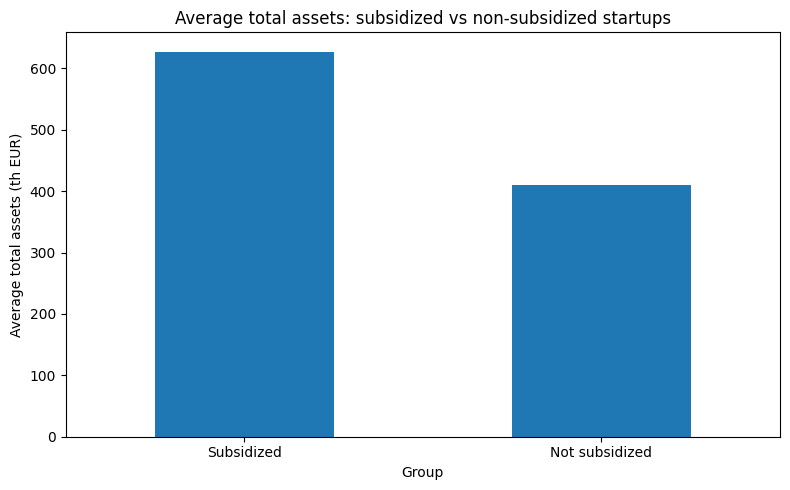

subsidy_status
Subsidized        627.2
Not subsidized    409.5
Name: total_assets_th_eur, dtype: Float64

In [20]:
# Required graph: average total assets comparison.

plot_data = (
    startup_panel_aida
    .dropna(subset=["total_assets_th_eur"])
    .groupby("subsidy_status")["total_assets_th_eur"]
    .mean()
    .reindex(["Subsidized", "Not subsidized"])
)

if plot_data.dropna().empty:
    print("No valid total assets data available for the comparison.")
else:
    ax = plot_data.plot(kind="bar", figsize=(8, 5))
    ax.set_title("Average total assets: subsidized vs non-subsidized startups")
    ax.set_xlabel("Group")
    ax.set_ylabel("Average total assets (th EUR)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_data.round(2)


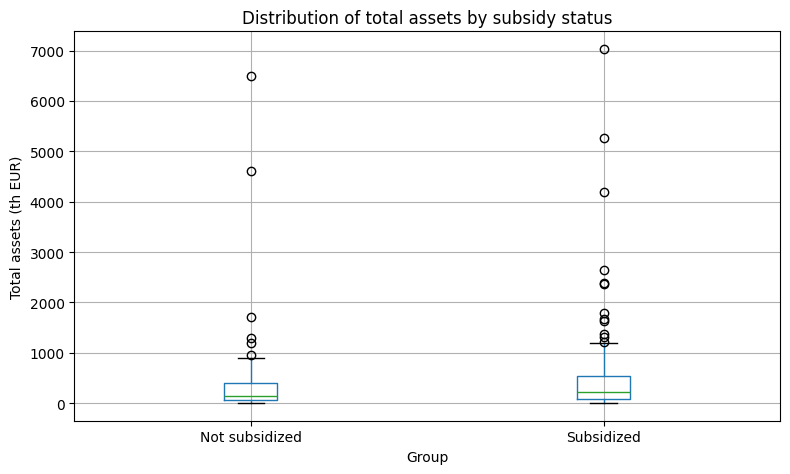

In [21]:
# Distribution comparison: total assets.
# This avoids relying only on the mean, which can be distorted by outliers.

valid_assets = startup_panel_aida.dropna(subset=["total_assets_th_eur"])

if valid_assets.empty:
    print("No valid total assets data available for boxplot.")
else:
    ax = valid_assets.boxplot(column="total_assets_th_eur", by="subsidy_status", figsize=(8, 5))
    ax.set_title("Distribution of total assets by subsidy status")
    ax.set_xlabel("Group")
    ax.set_ylabel("Total assets (th EUR)")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()


In [22]:
# Focus on startups without subsidies only.

id_non_presenti_analisi = startup_panel_aida.loc[startup_panel_aida["subsidized"] == 0].copy()

print("Non-subsidized startups:", id_non_presenti_analisi.shape[0])
print("Matched with AIDA:", id_non_presenti_analisi["Tax code number_clean"].notna().sum())
print("Not matched with AIDA:", id_non_presenti_analisi["Tax code number_clean"].isna().sum())

id_non_presenti_analisi[["codice fiscale", "codice fiscale_clean", "subsidy_status", "total_assets_th_eur", "revenue_th_eur", "ebitda_th_eur", "employees"]].head()


Non-subsidized startups: 74
Matched with AIDA: 74
Not matched with AIDA: 0


,codice fiscale,codice fiscale_clean,subsidy_status,total_assets_th_eur,revenue_th_eur,ebitda_th_eur,employees
0,05241520757,05241520757,Not subsidized,38,47,28,0
1,05230030750,05230030750,Not subsidized,256,27,12,1
2,05226230752,05226230752,Not subsidized,81,152,28,<NA>
3,08693310727,08693310727,Not subsidized,22,15,6,0
5,08679500721,08679500721,Not subsidized,86,130,2,2


In [23]:
# Descriptive statistics for non-subsidized startups.

non_subsidized_descriptives = id_non_presenti_analisi[
    ["total_assets_th_eur", "revenue_th_eur", "ebitda_th_eur", "employees"]
].describe().T

non_subsidized_descriptives.round(2)


,count,mean,std,min,25%,50%,75%,max
total_assets_th_eur,74.0,409.5,935.94,2.0,54.75,151.0,390.25,6500.0
revenue_th_eur,74.0,153.32,243.53,0.0,3.5,53.5,168.5,1158.0
ebitda_th_eur,74.0,-2.92,208.04,-1624.0,-3.0,6.0,27.5,476.0
employees,67.0,1.28,1.56,0.0,0.0,1.0,2.0,6.0


In [24]:
# Top non-subsidized startups by total assets.
# Useful to identify large startups that did not receive subsidies in the selected period/filter.

name_col = "denominazione" if "denominazione" in id_non_presenti_analisi.columns else None
cols_to_show = [col for col in [name_col, "codice fiscale_clean", "total_assets_th_eur", "revenue_th_eur", "ebitda_th_eur", "employees"] if col is not None]

top_non_subsidized_by_assets = (
    id_non_presenti_analisi
    .dropna(subset=["total_assets_th_eur"])
    .sort_values("total_assets_th_eur", ascending=False)
    [cols_to_show]
    .head(20)
)

top_non_subsidized_by_assets


,denominazione,codice fiscale_clean,total_assets_th_eur,revenue_th_eur,ebitda_th_eur,employees
137,OLOKER THERAPEUTICS S.R.L.,08507120726,6500,0,-172,5
34,SOCIETA' AGRICOLA INNOVATIVA LOIUDICE S.R.L.,08663550724,4613,274,96,0
10,ASTRADYNE S.R.L.,08573830729,1715,45,-111,4
49,DATA MASTERS S.R.L.,08720980724,1285,705,-189,6
23,RTLP SRL,02683850743,1196,0,-22,0
48,NEW ERA SMART SOLUTIONS AND TECHNOLOGIES S.R.L.,08654940728,956,191,132,2
8,ATP SCIENCE TECHNOLOGIES SOCIETA' A RESPONSABI...,08470190722,888,880,23,2
39,PUERAGE SOCIETA' A RESPONSABILITA' LIMITATA,08477810728,813,498,5,1
36,UPNOVA GROUP S.R.L.,08702030720,703,928,476,4
104,INTELLIGE S.R.L.,08540800722,656,1158,224,0


In [25]:
# Correlation matrix for non-subsidized startups.
# This checks whether size variables move together among firms without subsidies.

corr_vars = ["total_assets_th_eur", "revenue_th_eur", "ebitda_th_eur", "employees"]
non_subsidized_corr_data = id_non_presenti_analisi[corr_vars].dropna(how="all")

if non_subsidized_corr_data.shape[0] < 2:
    print("Not enough valid observations to compute correlations.")
else:
    non_subsidized_corr = non_subsidized_corr_data.corr()
    display(non_subsidized_corr.round(3))


,total_assets_th_eur,revenue_th_eur,ebitda_th_eur,employees
total_assets_th_eur,1.000,0.137,-0.014,0.309
revenue_th_eur,0.137,1.000,0.257,0.294
ebitda_th_eur,-0.014,0.257,1.000,-0.004
employees,0.309,0.294,-0.004,1.000


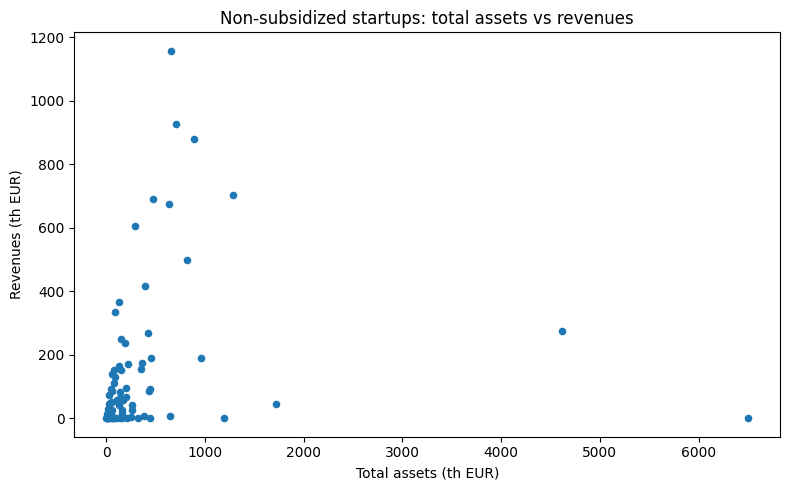

In [26]:
# Scatter plot for non-subsidized startups: total assets vs revenues.

scatter_data = id_non_presenti_analisi.dropna(subset=["total_assets_th_eur", "revenue_th_eur"])

if scatter_data.empty:
    print("No valid observations for total assets vs revenues scatter plot.")
else:
    ax = scatter_data.plot(
        x="total_assets_th_eur",
        y="revenue_th_eur",
        kind="scatter",
        figsize=(8, 5),
        title="Non-subsidized startups: total assets vs revenues",
    )
    ax.set_xlabel("Total assets (th EUR)")
    ax.set_ylabel("Revenues (th EUR)")
    plt.tight_layout()
    plt.show()


In [27]:
# Export the full analysis datasets.

startup_panel_aida.to_csv("startup_panel_subsidized_vs_not.csv", index=False)
id_non_presenti_analisi.to_csv("id_non_presenti_analisi.csv", index=False)
comparison_summary.to_csv("comparison_subsidized_vs_not.csv", index=False)

top_non_subsidized_by_assets.to_csv("top_non_subsidized_by_assets.csv", index=False)

print("Saved files:")
print("- startup_panel_subsidized_vs_not.csv")
print("- id_non_presenti_analisi.csv")
print("- comparison_subsidized_vs_not.csv")
print("- top_non_subsidized_by_assets.csv")


Saved files:
- startup_panel_subsidized_vs_not.csv
- id_non_presenti_analisi.csv
- comparison_subsidized_vs_not.csv
- top_non_subsidized_by_assets.csv


## 14. Merge subsidies with AIDA and subsidy categories

In [28]:
financials_subsidies_amount_per_company = total_subsidies_per_company.merge(
    aida,
    left_on="Identificativo nazionale",
    right_on="Tax code number_clean",
    how="left",
)

final_file = financials_subsidies_amount_per_company.merge(
    pivot_table_categories_across_firm,
    left_on="Identificativo nazionale",
    right_index=True,
    how="left",
)

for col in expected_categories + ["All"]:
    final_file[col] = final_file[col].fillna(0).astype(int)

final_file.to_csv(OUTPUT_FINAL_FILE, index=False)
print("Final file rows:", final_file.shape[0])
print("AIDA matched rows:", final_file["Tax code number_clean"].notna().sum())
final_file.head()

Final file rows: 79
AIDA matched rows: 79


,Identificativo nazionale,Elemento di aiuto Clean,Unnamed: 0,Company name,Province,Accounting closing date\nLast avail. yr,Number of employees\nLast avail. yr,Tax code number,CCIAA number,EBITDA\nth EUR\nLast avail. yr,EBITDA\nth EUR\n2024,EBITDA\nth EUR\n2023,EBITDA\nth EUR\n2022,EBITDA\nth EUR\n2021,EBITDA\nth EUR\n2020,EBITDA\nth EUR\n2019,EBITDA\nth EUR\n2018,EBITDA\nth EUR\n2017,EBITDA\nth EUR\n2016,EBITDA\nth EUR\n2015,Revenues from sales and services\nth EUR\nLast avail. yr,Revenues from sales and services\nth EUR\n2024,Revenues from sales and services\nth EUR\n2023,Revenues from sales and services\nth EUR\n2022,Revenues from sales and services\nth EUR\n2021,Revenues from sales and services\nth EUR\n2020,Revenues from sales and services\nth EUR\n2019,Revenues from sales and services\nth EUR\n2018,Revenues from sales and services\nth EUR\n2017,Revenues from sales and services\nth EUR\n2016,Revenues from sales and services\nth EUR\n2015,Total shareholder's funds\nth EUR\nLast avail. yr,Total shareholder's funds\nth EUR\n2024,Total shareholder's funds\nth EUR\n2023,Total shareholder's funds\nth EUR\n2022,Total shareholder's funds\nth EUR\n2021,Total shareholder's funds\nth EUR\n2020,Total shareholder's funds\nth EUR\n2019,Total shareholder's funds\nth EUR\n2018,Total shareholder's funds\nth EUR\n2017,Total shareholder's funds\nth EUR\n2016,Total shareholder's funds\nth EUR\n2015,Total assets\nth EUR\nLast avail. yr,Total assets\nth EUR\n2024,Total assets\nth EUR\n2023,Total assets\nth EUR\n2022,Total assets\nth EUR\n2021,Total assets\nth EUR\n2020,Total assets\nth EUR\n2019,Total assets\nth EUR\n2018,Total assets\nth EUR\n2017,Total assets\nth EUR\n2016,Total assets\nth EUR\n2015,Profit (loss)\nth EUR\nLast avail. yr,Profit (loss)\nth EUR\n2024,Profit (loss)\nth EUR\n2023,Profit (loss)\nth EUR\n2022,Profit (loss)\nth EUR\n2021,Profit (loss)\nth EUR\n2020,Profit (loss)\nth EUR\n2019,Profit (loss)\nth EUR\n2018,Profit (loss)\nth EUR\n2017,Profit (loss)\nth EUR\n2016,Profit (loss)\nth EUR\n2015,Added Value\nth EUR\nLast avail. yr,Added Value\nth EUR\n2024,Added Value\nth EUR\n2023,Added Value\nth EUR\n2022,Added Value\nth EUR\n2020,Added Value\nth EUR\n2021,Added Value\nth EUR\n2019,Added Value\nth EUR\n2018,Added Value\nth EUR\n2017,Added Value\nth EUR\n2016,Added Value\nth EUR\n2015,Turnover per employee\nEUR\nLast avail. yr,Turnover per employee\nEUR\n2024,Turnover per employee\nEUR\n2023,Turnover per employee\nEUR\n2022,Turnover per employee\nEUR\n2021,Turnover per employee\nEUR\n2020,Turnover per employee\nEUR\n2019,Turnover per employee\nEUR\n2018,Turnover per employee\nEUR\n2017,Turnover per employee\nEUR\n2016,Turnover per employee\nEUR\n2015,Total personnel costs\nth EUR\nLast avail. yr,Total personnel costs\nth EUR\n2024,Total personnel costs\nth EUR\n2023,Total personnel costs\nth EUR\n2022,Total personnel costs\nth EUR\n2020,Total personnel costs\nth EUR\n2021,Total personnel costs\nth EUR\n2019,Total personnel costs\nth EUR\n2018,Total personnel costs\nth EUR\n2017,Total personnel costs\nth EUR\n2016,Total personnel costs\nth EUR\n2015,Wages and salaries\nth EUR\nLast avail. yr,Wages and salaries\nth EUR\n2024,Wages and salaries\nth EUR\n2023,Wages and salaries\nth EUR\n2022,Wages and salaries\nth EUR\n2020,Wages and salaries\nth EUR\n2021,Wages and salaries\nth EUR\n2019,Wages and salaries\nth EUR\n2018,Wages and salaries\nth EUR\n2017,Wages and salaries\nth EUR\n2016,Wages and salaries\nth EUR\n2015,Ind. patents and intellect. property rights\nth EUR\nLast avail. yr,Ind. patents and intellect. property rights\nth EUR\n2024,Ind. patents and intellect. property rights\nth EUR\n2023,Ind. patents and intellect. property rights\nth EUR\n2022,Ind. patents and intellect. property rights\nth EUR\n2021,Ind. patents and intellect. property rights\nth EUR\n2020,Ind. patents and intellect. property rights\nth EUR\n2019,Ind. patents and intellect. property rights\nth EUR\n2018,Ind. patents and intellect. property rights\nth

## 15. Policy design

/var/folders/2d/wjxmfgl117n50psffqznh7z40000gn/T/ipykernel_45268/1256338972.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


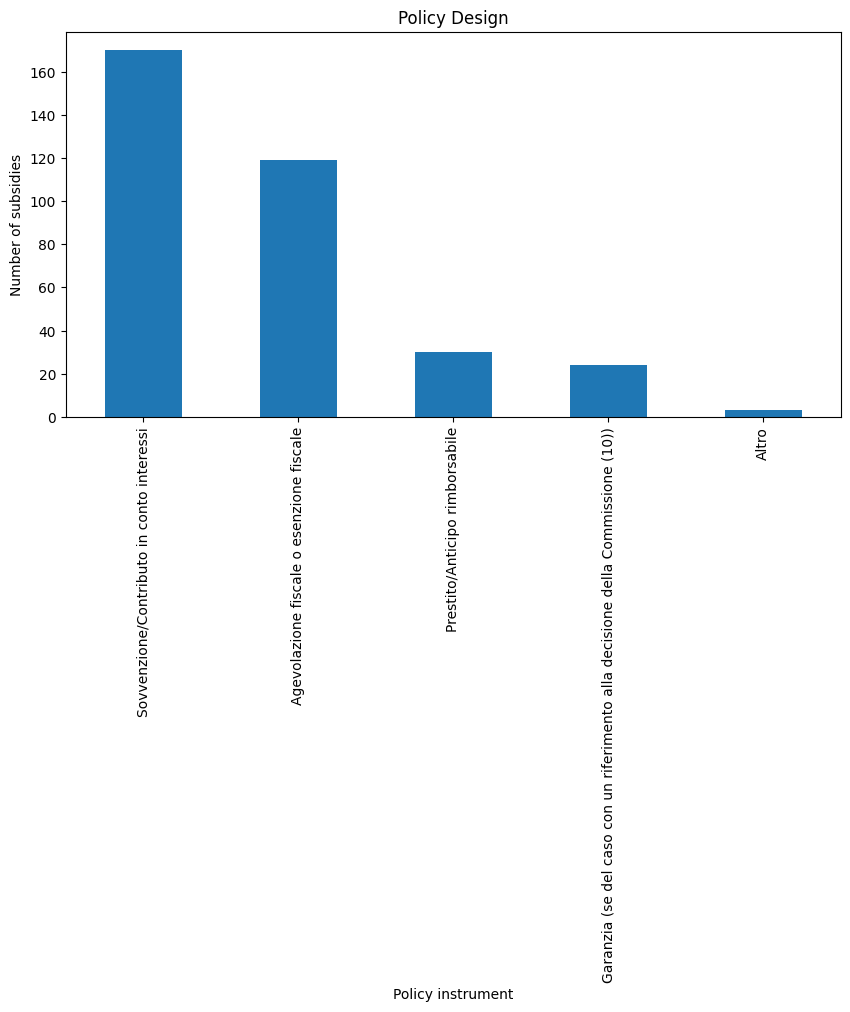

In [29]:
if "Strumento di aiuto" in remove_dup.columns:
    pol_des = remove_dup["Strumento di aiuto"].value_counts()
    ax = pol_des.plot(kind="bar", title="Policy Design", figsize=(10, 5))
    ax.set_xlabel("Policy instrument")
    ax.set_ylabel("Number of subsidies")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Strumento di aiuto' not found.")

## 16. Distribution of subsidies

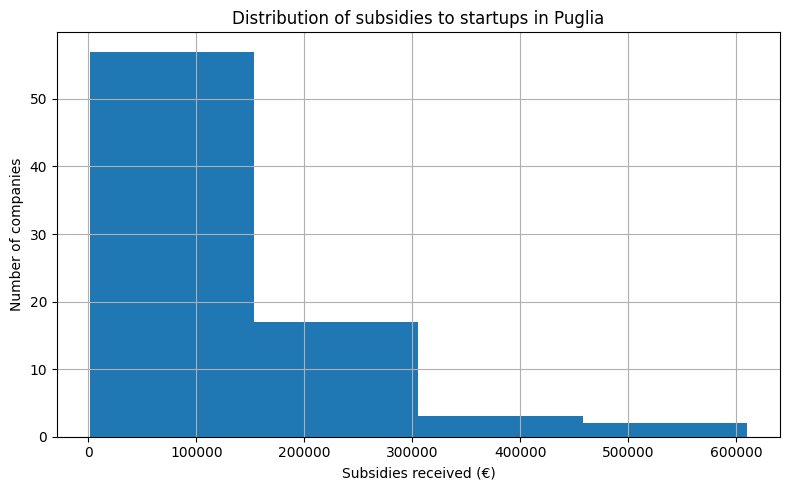

In [30]:
ax = final_file["Elemento di aiuto Clean"].hist(bins=4, figsize=(8, 5))
ax.set_xlabel("Subsidies received (€)")
ax.set_ylabel("Number of companies")
ax.set_title("Distribution of subsidies to startups in Puglia")
plt.tight_layout()
plt.show()

## 17. Concentration: top and bottom groups

In [31]:
total_subsidies = final_file["Elemento di aiuto Clean"].sum()

if total_subsidies == 0:
    print("Total subsidies are zero. Concentration indicators cannot be computed.")
else:
    quantile_90 = final_file["Elemento di aiuto Clean"].quantile(0.90)
    top_10_absolute = final_file.loc[final_file["Elemento di aiuto Clean"] > quantile_90, "Elemento di aiuto Clean"].sum()
    weight_top_10 = top_10_absolute / total_subsidies * 100
    print(f"The top 10% of companies receive {weight_top_10:.2f}% of total subsidies")

    quantile_75 = final_file["Elemento di aiuto Clean"].quantile(0.75)
    top_25_absolute = final_file.loc[final_file["Elemento di aiuto Clean"] > quantile_75, "Elemento di aiuto Clean"].sum()
    weight_top_25 = top_25_absolute / total_subsidies * 100
    print(f"The top 25% of companies receive {weight_top_25:.2f}% of total subsidies")

    quantile_50 = final_file["Elemento di aiuto Clean"].quantile(0.50)
    bottom_50_absolute = final_file.loc[final_file["Elemento di aiuto Clean"] <= quantile_50, "Elemento di aiuto Clean"].sum()
    weight_bottom_50 = bottom_50_absolute / total_subsidies * 100
    print(f"The bottom 50% of companies receive {weight_bottom_50:.2f}% of total subsidies")

The top 10% of companies receive 35.10% of total subsidies
The top 25% of companies receive 66.51% of total subsidies
The bottom 50% of companies receive 10.86% of total subsidies


## 18. Subsidies vs EBITDA

In [32]:
df.columns = df.columns.str.replace("\n", " ").str.strip()

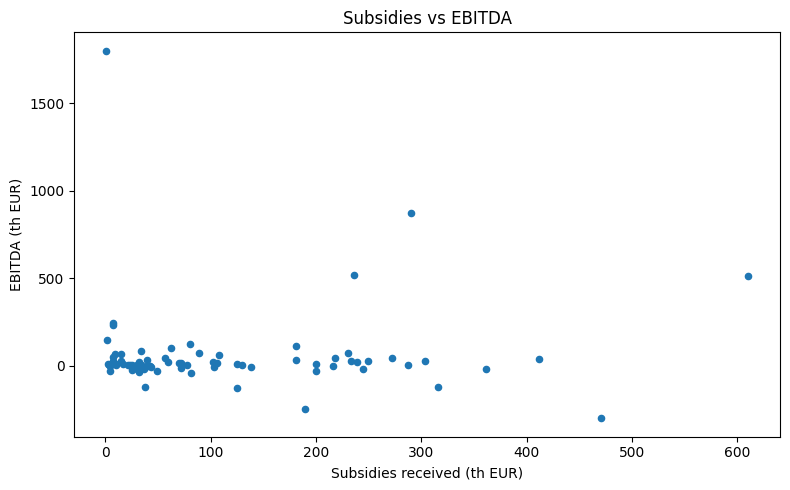

Correlation subsidies vs EBITDA: 0.03453


In [33]:
ebitda_col = "EBITDA\nth EUR\nLast avail. yr"
if ebitda_col in final_file.columns:
    final_file["EBITDA clean last av yr"] = clean_thousand_number(final_file[ebitda_col])
    final_file["Elemento di aiuto Clean in th"] = final_file["Elemento di aiuto Clean"] / 1000

    final_file.plot(
        x="Elemento di aiuto Clean in th",
        y="EBITDA clean last av yr",
        kind="scatter",
        title="Subsidies vs EBITDA",
        figsize=(8, 5),
    )
    plt.xlabel("Subsidies received (th EUR)")
    plt.ylabel("EBITDA (th EUR)")
    plt.tight_layout()
    plt.show()

    test_corr = final_file[["Elemento di aiuto Clean in th", "EBITDA clean last av yr"]].dropna()
    if len(test_corr) >= 2:
        corr = test_corr.corr().iloc[0, 1]
        print(f"Correlation subsidies vs EBITDA: {corr:.5f}")
    else:
        print("Not enough valid observations to compute correlation.")
else:
    print(f"Column not found: {ebitda_col}")

## 19. Subsidy dependence on revenues

9     12487.84
16      7214.5
7       5746.4
3      4522.82
42     4302.66
36     3508.56
51      3209.0
31     2028.04
25     1250.07
56      975.78
17      952.38
33      780.34
45      493.75
23      407.17
57      398.34
27      394.63
4       313.15
15      303.56
49      198.54
13      192.55
Name: subsidy_dependence, dtype: Float64
Companies with normal dependence (<200%): 47
Companies with extreme dependence (>=200%): 18


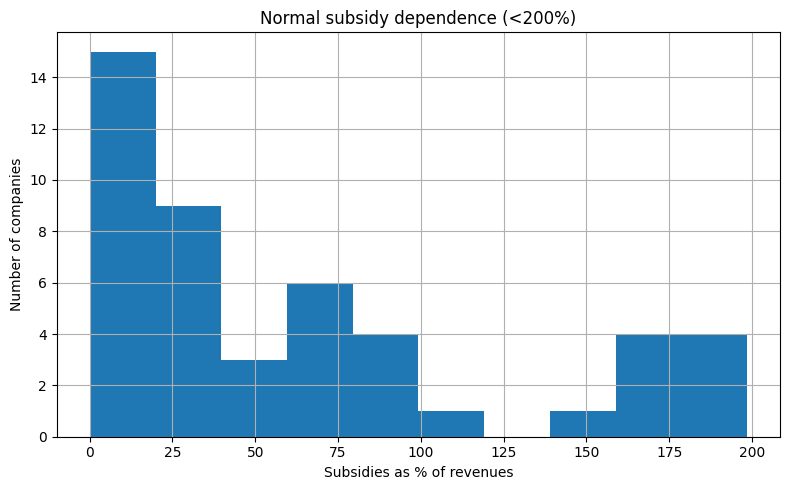

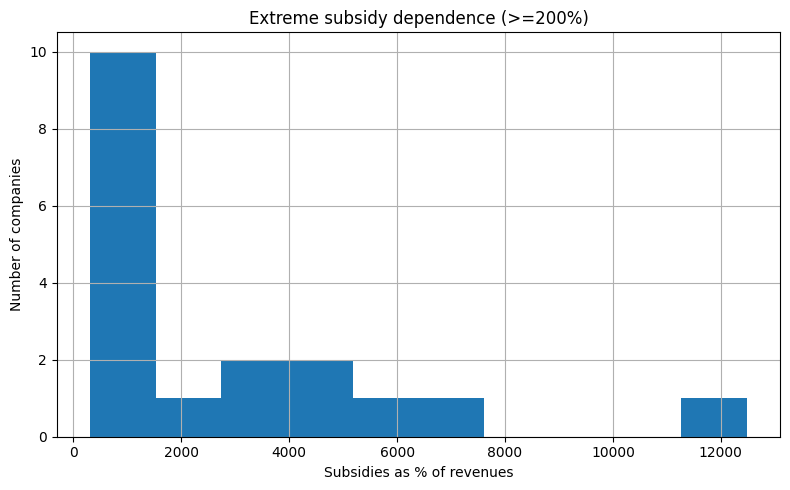

Companies with subsidies > revenues: 28 out of 79 (35.4%)


In [34]:
revenue_col = "Revenues from sales and services\nth EUR\nLast avail. yr"
if revenue_col in final_file.columns:
    final_file["Revenue clean last av yr"] = clean_thousand_number(final_file[revenue_col])
    final_file["subsidy_dependence"] = (
        final_file["Elemento di aiuto Clean in th"] / final_file["Revenue clean last av yr"] * 100
    ).round(2)
    final_file["subsidy_dependence"] = final_file["subsidy_dependence"].replace([np.inf, -np.inf], np.nan)

    print(final_file["subsidy_dependence"].sort_values(ascending=False).head(20))

    mask_normal = (final_file["subsidy_dependence"] > 0) & (final_file["subsidy_dependence"] < 200)
    mask_extreme = final_file["subsidy_dependence"] >= 200

    print(f"Companies with normal dependence (<200%): {mask_normal.sum()}")
    print(f"Companies with extreme dependence (>=200%): {mask_extreme.sum()}")

    ax = final_file.loc[mask_normal, "subsidy_dependence"].hist(bins=10, figsize=(8, 5))
    ax.set_title("Normal subsidy dependence (<200%)")
    ax.set_xlabel("Subsidies as % of revenues")
    ax.set_ylabel("Number of companies")
    plt.tight_layout()
    plt.show()

    if mask_extreme.sum() > 0:
        ax = final_file.loc[mask_extreme, "subsidy_dependence"].hist(bins=10, figsize=(8, 5))
        ax.set_title("Extreme subsidy dependence (>=200%)")
        ax.set_xlabel("Subsidies as % of revenues")
        ax.set_ylabel("Number of companies")
        plt.tight_layout()
        plt.show()

    mask_over_100_subsidy = final_file["subsidy_dependence"] > 100
    count_over_100 = mask_over_100_subsidy.sum()
    total = final_file.shape[0]
    print(f"Companies with subsidies > revenues: {count_over_100} out of {total} ({count_over_100 / total * 100:.1f}%)")
else:
    print(f"Column not found: {revenue_col}")

## 20. Bar charts: subsidy categories

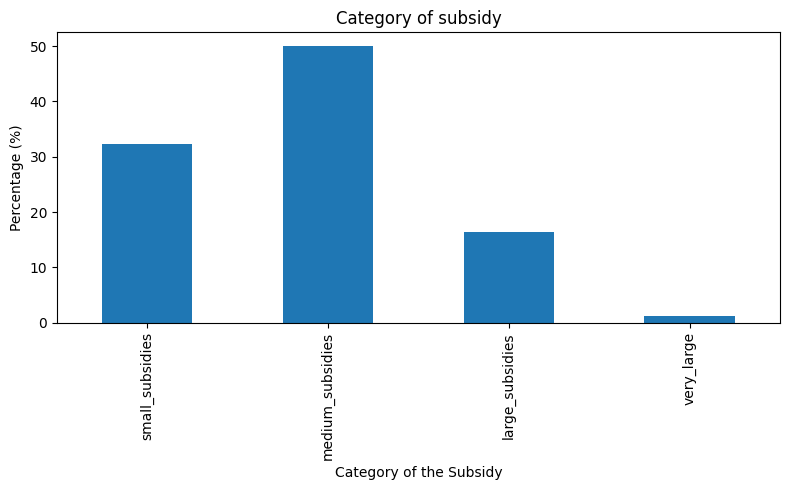

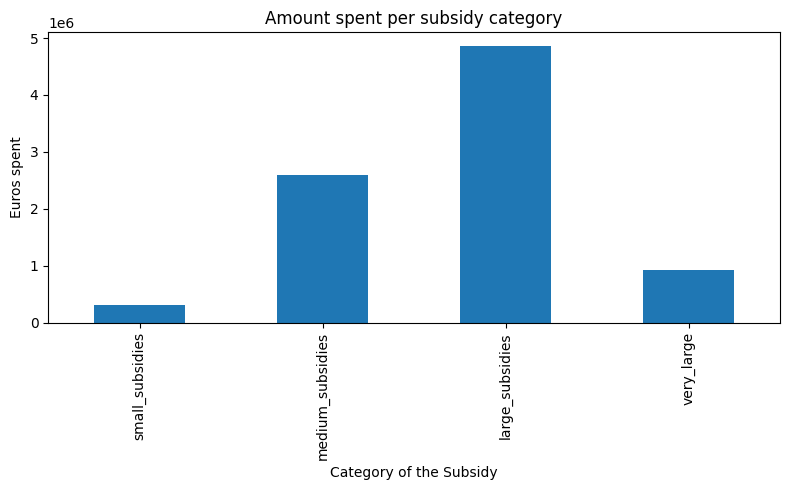

In [35]:
amount_per_each_category = remove_dup.groupby("Category of the Subsidy")["Elemento di aiuto Clean"].sum()
order = ["small_subsidies", "medium_subsidies", "large_subsidies", "very_large"]
amount_per_each_category = amount_per_each_category.reindex(order).fillna(0)

ax = concentration_subsidies_perc.reindex(order).fillna(0).plot(
    kind="bar",
    title="Category of subsidy",
    ylabel="Percentage (%)",
    figsize=(8, 5),
)
plt.tight_layout()
plt.show()

ax = amount_per_each_category.plot(
    kind="bar",
    title="Amount spent per subsidy category",
    ylabel="Euros spent",
    figsize=(8, 5),
)
plt.tight_layout()
plt.show()